# Unsupervised Learning — Data Preparation

**Predicting the Predictor: Regime-Based Error Analysis of BondDroid vs. TRACE**

This notebook prepares the aligned BondDroid/TRACE panel for clustering. It continues the data cleaning work done by Christian in `aligned_trade_panel.parquet`, where each row is a TRACE trade matched to the most recent prior BondDroid signal (within 3600 s).

### Pipeline
1. **Profile** the panel (shape, dtypes, missingness).
2. **Clean**: drop a tiny set of BondDroid pricing failures.
3. **Engineer** clustering features (time-to-maturity, log transforms, OAS/spread midpoints, cyclical time-of-day).
4. **Reduce redundancy** using correlation.
5. **Scale** with `RobustScaler`.
6. **Persist** the feature matrix plus held-aside columns for post-clustering error analysis.

### Leakage guard
The residual error target (`bd_mid_px − trace_price`) and its components (`trace_price`, `trace_yield`) are **excluded** from the clustering feature set. They are retained as held-aside columns so we can compare BondDroid error *across* clusters after the fact.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Paths (data/ is gitignored; files arrive via the shared Drive)
PANEL_PATH = "data/trace_pull/aligned_trade_panel.parquet"
OUT_DIR = "data/clustering"
FIG_DIR = "outputs/unsupervised"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42

## 1. Profile the panel

Each row is one TRACE trade matched to the most recent BondDroid signal. Before touching features we quantify structure and missingness.

In [3]:
raw = pd.read_parquet(PANEL_PATH)

print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} cols")
print(f"Unique CUSIPs: {raw['cusip'].nunique():,} | Unique FIGIs: {raw['FIGI'].nunique():,}")
print(f"Trade-time range: {raw['trade_ts'].min()} to {raw['trade_ts'].max()}")
print(f"Snapshot quotes (is_snapshot): {raw['is_snapshot'].mean()*100:.1f}%")

missing = raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nColumns with missing values:")
for col, n in missing.items():
    print(f"  {col:28s} {n:>10,} ({n/len(raw)*100:5.2f}%)")

Raw shape: 8,509,326 rows x 30 cols
Unique CUSIPs: 2,237 | Unique FIGIs: 2,204
Trade-time range: 2023-10-05 23:31:28 to 2025-03-18 20:54:41
Snapshot quotes (is_snapshot): 94.7%

Columns with missing values:
  AVG_DAILY_TRADE_COUNT_60         29,431 ( 0.35%)
  TIMES_TRADED_60                  29,431 ( 0.35%)
  TIME_SINCE_LAST_TRADE            29,431 ( 0.35%)
  trace_yield                      12,090 ( 0.14%)


As we can see, the raw dataset contains 8,509,326 rows across 30 columns, covering 2,237 unique CUSIPs (2,204 unique FIGIs) over a trade-time window from Oct 5, 2023 to Mar 18, 2025 (~17 months).

The vast majority of records (94.7%) are snapshot quotes (`is_snapshot`). Pricing-failure prevalence and quote-age distribution are characterized in the BondDroid EDA notebook and revisited in the Cleaning section below, so they are not re-plotted here.

Missing values are minimal and concentrated in a few trade-activity features. The three 60-day trade-activity fields share an identical missingness count (29,431), suggesting they go null together. Overall data completeness is high (>99.6% across all columns).

In [4]:
# Why are there more unique CUSIPs (2,237) than FIGIs (2,204)?
# Either some rows have a null FIGI, or multiple CUSIPs share one FIGI (many-to-one).
print(f"CUSIP nulls: {raw['cusip'].isna().sum():,}")
print(f"FIGI  nulls: {raw['FIGI'].isna().sum():,}")

# FIGIs that map to more than one CUSIP (many-to-one mapping)
cusips_per_figi = raw.groupby("FIGI")["cusip"].nunique()
multi_figi = cusips_per_figi[cusips_per_figi > 1].sort_values(ascending=False)
print(f"\nFIGIs mapping to >1 CUSIP: {len(multi_figi):,}")
print(f"Extra CUSIPs explained by many-to-one: {(multi_figi - 1).sum():,}")
print(multi_figi.head(10))

# Reverse check: any CUSIP mapping to more than one FIGI?
figis_per_cusip = raw.groupby("cusip")["FIGI"].nunique()
print(f"\nCUSIPs mapping to >1 FIGI: {(figis_per_cusip > 1).sum():,}")

CUSIP nulls: 0
FIGI  nulls: 0

FIGIs mapping to >1 CUSIP: 30
Extra CUSIPs explained by many-to-one: 33
FIGI
BBG009PNW3Z2    4
BBG01LQ6C916    3
BBG000034M81    2
BBG00VYKHL59    2
BBG01SJ1WHN6    2
BBG01SCGSBN8    2
BBG01LTHZ2G3    2
BBG01GSD93V4    2
BBG01F7QXLC4    2
BBG015CV0B55    2
Name: cusip, dtype: int64

CUSIPs mapping to >1 FIGI: 0


## 2. Cleaning

**BondDroid pricing failures.** The panel includes a `bd_pricing_failure` flag (impossible mid-yields, |OAS| > 2000 bps, or |spread-over-Treasury| > 21000). It marks ~0.1% of rows. These are genuine model failures, so we drop them for clustering rather than let them seed junk clusters. (Carter keeps them on the supervised side as large-error cases.)

**Snapshot vs event-driven quotes.** About 95% of matched quotes (`is_snapshot`) are hourly "close" snapshots rather than event-driven refreshes. We keep them: `quote_age_seconds` (median ~31 min) already encodes how stale each quote is, giving clustering an explicit staleness axis instead of discarding 95% of the data.

In [5]:
df = raw.copy()

# Drop BondDroid pricing failures (flagged in the panel)
n_fail = int(df["bd_pricing_failure"].sum())
df = df[~df["bd_pricing_failure"]].copy()
print(f"Dropped BondDroid pricing failures (bd_pricing_failure): {n_fail:,}")

print(f"\nClean panel: {len(df):,} rows "
      f"({len(df)/len(raw)*100:.1f}% of raw) | "
      f"{df['cusip'].nunique():,} CUSIPs")

Dropped BondDroid pricing failures (bd_pricing_failure): 8,749

Clean panel: 8,500,577 rows (99.9% of raw) | 2,235 CUSIPs


## 3. Feature engineering

Clustering is done on **liquidity, maturity, trading activity, spread behavior, and market conditions**. I engineered:

| Feature | Source | Explanation |
|---|---|---|
| `ttm_years` | `MATURITY − trade_ts` | Maturity remaining — a core risk/structure dimension |
| `log_volume` | `log1p(trade_volume)` | Trade size spans 9 orders of magnitude; log tames it |
| `log_avg_daily_trades` | `log1p(AVG_DAILY_TRADE_COUNT_60)` | Liquidity / trading frequency (heavy right tail) |
| `oas_mid` | `(BID_OAS + ASK_OAS)/2`, winsorized 1/99 | Credit + liquidity spread level |
| `bd_px_spread` | as-is (winsorized) | Bid–ask price spread — direct liquidity proxy |
| `hour_sin`, `hour_cos` | hour of `bd_ts` | Cyclical time-of-day (market-condition proxy) |

Missing liquidity stats (`AVG_DAILY_TRADE_COUNT_60`, ~0.4%) mean the bond had no recent trades; we treat those as 0 trades before the log. Heavy-tailed level features are winsorized at the 1st/99th percentile so a handful of extreme BondDroid quotes don't dominate distances.

In [6]:
df["MATURITY"] = pd.to_datetime(df["MATURITY"], errors="coerce")
df["trade_ts"] = pd.to_datetime(df["trade_ts"], errors="coerce")
df["bd_ts"] = pd.to_datetime(df["bd_ts"], errors="coerce")

# Time to maturity (years) from the trade execution timestamp
df["ttm_years"] = (df["MATURITY"] - df["trade_ts"]).dt.days / 365.25

# Liquidity: missing recent-trade stats -> 0 trades, then log
df["log_avg_daily_trades"] = np.log1p(df["AVG_DAILY_TRADE_COUNT_60"].fillna(0.0))
df["log_volume"] = np.log1p(df["trade_volume"])

# OAS midpoint
df["oas_mid"] = (df["BID_OAS"] + df["ASK_OAS"]) / 2.0

# Cyclical time-of-day from BondDroid signal timestamp
hour = df["bd_ts"].dt.hour + df["bd_ts"].dt.minute / 60.0
df["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)

# Winsorize heavy-tailed level features at 1st/99th percentile
def winsorize(s, lo=0.01, hi=0.99):
    ql, qh = s.quantile(lo), s.quantile(hi)
    return s.clip(ql, qh)

for col in ["oas_mid", "bd_px_spread", "bd_mid_yield", "log_volume", "log_avg_daily_trades", "ttm_years"]:
    df[col] = winsorize(df[col])

print("Engineered features (post-winsorize) summary:")
print(df[["ttm_years", "log_volume", "log_avg_daily_trades",
          "oas_mid", "bd_px_spread", "hour_sin", "hour_cos"]].describe().round(3).to_string())

Engineered features (post-winsorize) summary:
         ttm_years   log_volume  log_avg_daily_trades      oas_mid  bd_px_spread     hour_sin     hour_cos
count  8500577.000  8500577.000           8500577.000  8500577.000   8500577.000  8500577.000  8500577.000
mean         7.380       10.303                 3.028      107.123         0.171       -0.130       -0.823
std          7.772        1.955                 0.748      100.778         0.182        0.526        0.171
min          0.194        5.303                 1.811        7.348         0.031       -1.000       -1.000
25%          2.552        8.987                 2.423       53.798         0.045       -0.707       -0.966
50%          4.882       10.127                 2.931       79.642         0.103       -0.259       -0.866
75%          8.613       11.513                 3.548      119.154         0.222        0.259       -0.707
max         36.348       15.425                 4.735      595.379         1.002        1.000     

## 4. Redundancy reduction

Spearman correlations on the candidate features reveal near-duplicate pairs. We keep one representative from each redundant pair to avoid double-weighting a dimension in the distance metric:

- `DURATION_MID` ≈ `CONVEXITY_MID` (ρ ≈ 1.00) → keep **`DURATION_MID`**
- `DURATION_MID` ≈ `ttm_years` (ρ ≈ 1.00) → keep **`DURATION_MID`** (interest-rate sensitivity subsumes raw maturity here; `ttm_years` is retained as a held-aside column for interpretation)
- `oas_mid` ≈ spread-over-Treasury midpoint (ρ ≈ 0.98) → keep **`oas_mid`**
- `AVG_DAILY_TRADE_COUNT_60` ≈ `TIMES_TRADED_60` (ρ ≈ 0.99) → keep **`log_avg_daily_trades`**

`quote_age_seconds` is essentially uncorrelated with the other features (ρ ≈ 0), so it contributes an independent "quote staleness" axis and is valuable to keep. The remaining moderate correlations (e.g. `bd_px_spread` with `DURATION_MID` ≈ 0.83, `oas_mid` with `bd_mid_yield` ≈ 0.78) are kept: they capture conceptually distinct liquidity / credit / rate-level dimensions and none are rank-identical.

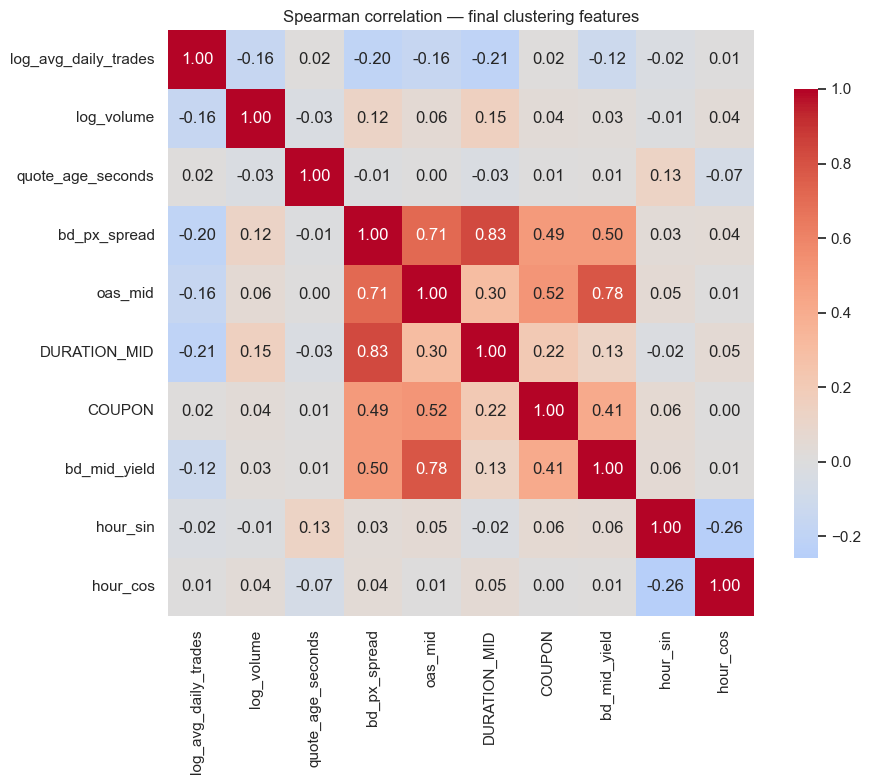

Max |off-diagonal| correlation among selected features: 0.83


In [7]:
# Final clustering feature set (numeric, post-redundancy reduction)
CLUSTER_FEATURES = [
    "log_avg_daily_trades",  # liquidity / trading frequency
    "log_volume",            # trade size
    "quote_age_seconds",     # quote staleness (orthogonal axis)
    "bd_px_spread",          # bid-ask spread (liquidity)
    "oas_mid",               # credit + liquidity spread level
    "DURATION_MID",          # interest-rate sensitivity (subsumes ttm_years, rho=1.00)
    "COUPON",                # structural
    "bd_mid_yield",          # yield level
    "hour_sin", "hour_cos",  # cyclical time-of-day
]

# Confirm low redundancy among the selected features
corr = df[CLUSTER_FEATURES].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Spearman correlation — final clustering features")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/feature_correlation.png", dpi=120)
plt.show()

max_off = (corr.abs() - np.eye(len(corr))).max().max()
print(f"Max |off-diagonal| correlation among selected features: {max_off:.2f}")

## 5. Scaling

Distance-based clustering (K-Means, GMM) requires comparably-scaled features. Even after log/winsorize, several features keep moderate tails, so we use **`RobustScaler`** (centers on the median, scales by the IQR) rather than `StandardScaler`, which is sensitive to the remaining outliers.

We keep the categorical descriptors (`BONDDROID_SECTOR`, `REGION`, `MARKET_SEGMENT`, etc.) **out of the distance metric**. Cluster interpretation relies on the original financial features; one-hot encoding 16+ sectors would let sparse binary columns dominate Euclidean distance. They are retained as label columns for post-clustering profiling instead.

In [8]:
feat = df[CLUSTER_FEATURES].copy()

scaler = RobustScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(feat),
    columns=[f"{c}__z" for c in CLUSTER_FEATURES],
    index=df.index,
)

# Held-aside columns: identifiers, error components (leakage guard), profiling labels
PROFILE_COLS = [
    "cusip", "FIGI", "bd_ts", "trade_ts",
    "trace_price", "bd_mid_px", "trace_yield",          # error analysis (NOT clustered on)
    "BONDDROID_SECTOR", "BONDDROID_INDUSTRY", "REGION",
    "MARKET_SEGMENT", "TRIGGER_TYPE", "trade_side",
    "TIME_SINCE_LAST_TRADE", "is_snapshot", "ttm_years",
]
held = df[PROFILE_COLS].copy()

# Post-hoc error metric for cluster comparison (kept aside, not a feature)
held["abs_price_error"] = (df["bd_mid_px"] - df["trace_price"]).abs()

out = pd.concat([held.reset_index(drop=True),
                 feat.reset_index(drop=True).add_suffix("__raw"),
                 scaled.reset_index(drop=True)], axis=1)
print(f"Output matrix: {out.shape[0]:,} rows x {out.shape[1]} cols")
print(f"Scaled feature columns ({len(CLUSTER_FEATURES)}): {[c+'__z' for c in CLUSTER_FEATURES]}")

Output matrix: 8,500,577 rows x 37 cols
Scaled feature columns (10): ['log_avg_daily_trades__z', 'log_volume__z', 'quote_age_seconds__z', 'bd_px_spread__z', 'oas_mid__z', 'DURATION_MID__z', 'COUPON__z', 'bd_mid_yield__z', 'hour_sin__z', 'hour_cos__z']


## 6. Distribution check

Scaled feature distributions, to confirm transformations and there are no zero-variance columns going into clustering.

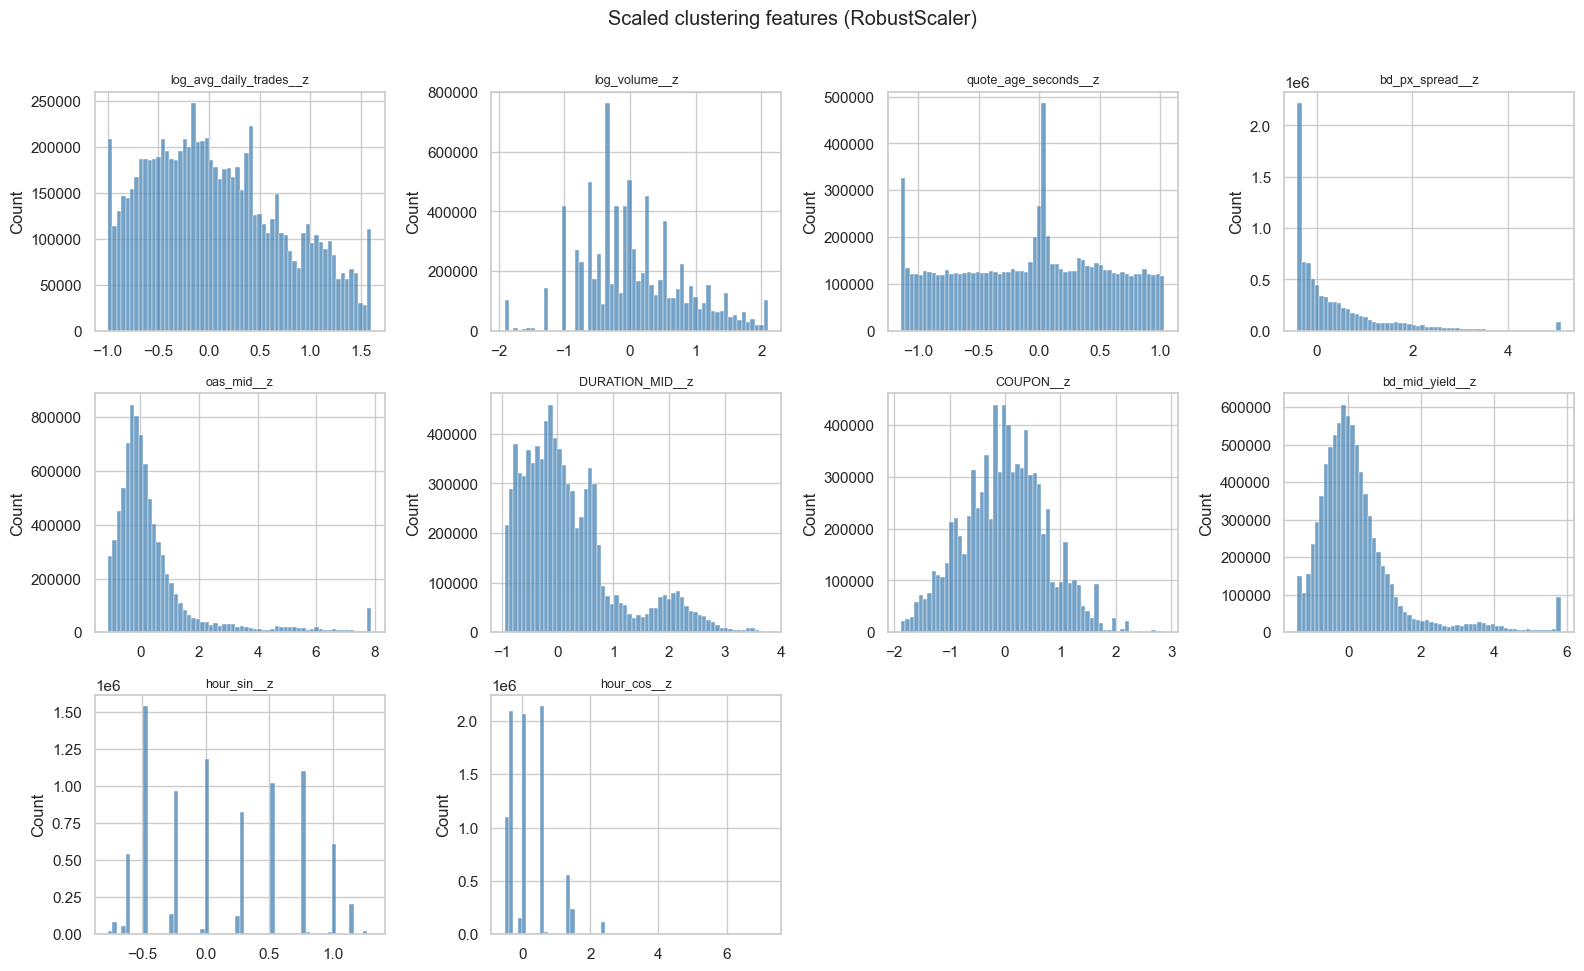

Variance of scaled features (all should be > 0):
log_avg_daily_trades__z    0.442
log_volume__z              0.599
quote_age_seconds__z       0.375
bd_px_spread__z            1.070
oas_mid__z                 2.378
DURATION_MID__z            0.769
COUPON__z                  0.571
bd_mid_yield__z            1.440
hour_sin__z                0.297
hour_cos__z                0.438


In [9]:
scaled_cols = [f"{c}__z" for c in CLUSTER_FEATURES]
ncol = 4
nrow = int(np.ceil(len(scaled_cols) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(16, 3.2 * nrow))
for ax, col in zip(axes.ravel(), scaled_cols):
    sns.histplot(out[col], bins=60, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
for ax in axes.ravel()[len(scaled_cols):]:
    ax.set_visible(False)
plt.suptitle("Scaled clustering features (RobustScaler)", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/scaled_feature_distributions.png", dpi=120)
plt.show()

print("Variance of scaled features (all should be > 0):")
print(out[scaled_cols].var().round(3).to_string())

## 7. Persist the clustering-ready matrix

Saved to `data/clustering/clustering_features.parquet`. Columns:
- `*__z` — scaled features for clustering (the matrix to feed K-Means / GMM / HDBSCAN)
- `*__raw` — pre-scaling engineered values (for interpretation)
- identifiers, categorical labels, and `abs_price_error` — held aside for post-clustering profiling and error comparison (never used to form clusters)

In [10]:
out_path = f"{OUT_DIR}/clustering_features.parquet"
out.to_parquet(out_path, index=False)

print(f"  rows: {len(out):,}")
print(f"  scaled feature cols: {len(scaled_cols)}")
print(f"  retained for profiling: {len(PROFILE_COLS) + 1}")

  rows: 8,500,577
  scaled feature cols: 10
  retained for profiling: 17
